In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("cleaned_data.csv")

The goal for this week is to create a pipeline for data cleaning and save a csv file after cleaning. We discussed in class the primary cleaning categories being Data type fixes, Missing values, Standardization, and Obvious errors. After our group conversation with Sibi we discussed a two week plan to handle my data due to its nature. This week I will be focusing on removing the general and movement articles, formatting the published_at column date so that it can be read by yFinance which is what is going to be used to determine the changes in stock price after article publication dates, I will investigate how the number of valid publishers changes as I impose limits on the minimum number of articles written because each publisher needs to write enough articles to have enough data to be classified, and lastly I will add the initial plan for stock price after publication to the columns. As discussed in previous work, there are no missing values or obvious errors. 

Next week, on top of the regular assignment, I will try to figure out how to classify whether the articles are talking about short term or long term prediction or analysis and add the appropriate yFinance columns after aligning dates to next trading dates and determining how to ensure the interval ends on a trading day.

In [3]:
data.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE,Analysis
1,21992,Stocks That Hit 52-Week Highs On Thursday,https://www.benzinga.com/news/20/06/16180865/s...,Benzinga Insights,2020-06-04 10:48:11-04:00,ADBE,Movement
2,21993,Shares of several companies in the broader tec...,https://www.benzinga.com/wiim/20/05/16116988/s...,Benzinga Newsdesk,2020-05-27 10:24:38-04:00,ADBE,Movement
3,21994,Stocks That Hit 52-Week Highs On Tuesday,https://www.benzinga.com/news/20/05/16106805/s...,Benzinga Insights,2020-05-26 10:32:14-04:00,ADBE,Movement
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE,Analysis


Removing the General and Movement article types.

In [5]:
len(data)

107805

In [6]:
data['Headline_Class'].value_counts()

Headline_Class
General       48544
Movement      28957
Analysis      25965
Prediction     4339
Name: count, dtype: int64

In [7]:
new_data = data[data['Headline_Class'].isin(['Analysis', 'Prediction'])].copy()

In [8]:
len(new_data)

30304

In [9]:
new_data['Headline_Class'].value_counts()

Headline_Class
Analysis      25965
Prediction     4339
Name: count, dtype: int64

Investigating the publishers left and the amount of articles they wrote

In [ ]:
new_data["publisher"].value_counts() #360 publishers left after removing 70% of the data due to general or movement articles 

publisher
Paul Quintaro                  4244
Charles Gross                  2889
Benzinga Newsdesk              2428
Lisa Levin                     2321
Vick Meyer                     1968
                               ... 
Abhi Rao                          1
Steve Evans - MoneyGeek.com       1
KomfieM                           1
Dave Moenning                     1
Ian Kar                           1
Name: count, Length: 360, dtype: int64

In [11]:
new_data["publisher"].value_counts().describe()

count     360.000000
mean       84.177778
std       364.280833
min         1.000000
25%         1.000000
50%         5.000000
75%        22.250000
max      4244.000000
Name: count, dtype: float64

Text(0.5, 1.0, 'Articles published per publisher')

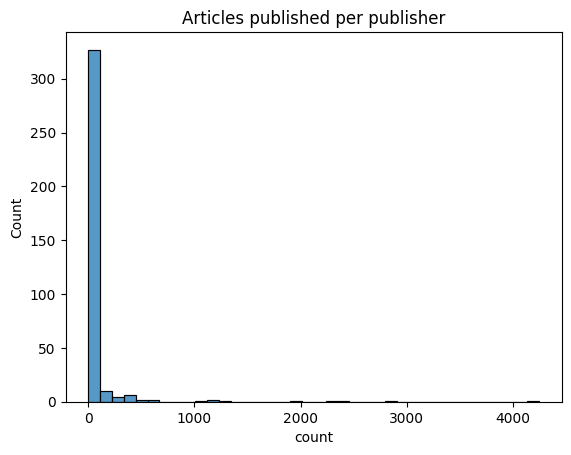

In [13]:
sns.histplot(new_data["publisher"].value_counts())
plt.title('Articles published per publisher')


In [16]:
publisher_thresholds = [5, 10, 25, 50, 100, 1000]
for amount in publisher_thresholds:
    print(f"Threshold {amount}: {(new_data['publisher'].value_counts() >= amount).sum()} publishers left")

Threshold 5: 186 publishers left
Threshold 10: 140 publishers left
Threshold 25: 86 publishers left
Threshold 50: 59 publishers left
Threshold 100: 37 publishers left
Threshold 1000: 9 publishers left


Unfortunately most of the publishers do not actually publish a lot of articles. For now I am going to make the minimum threshold to be classified by a model 25 articles which leaves 86 publishers left but will revisit after discussion in class.

In [17]:
publisher_amount = new_data['publisher'].value_counts()
publisher_cutoff = publisher_amount[publisher_amount >= 25].index
data_filtered_publisher = new_data[new_data['publisher'].isin(publisher_cutoff)].copy()

In [18]:
len(data_filtered_publisher)

28863

In [19]:
data_filtered_publisher.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE,Analysis
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE,Analysis
5,21996,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14 09:31:09-04:00,ADBE,Analysis
6,21997,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14 06:19:39-04:00,ADBE,Analysis
9,22000,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30 10:03:54-04:00,ADBE,Analysis


In [20]:
data_filtered_publisher["publisher"].value_counts().describe()

count      86.000000
mean      335.616279
std       690.161416
min        25.000000
25%        42.500000
50%        75.000000
75%       266.750000
max      4244.000000
Name: count, dtype: float64

For now every publisher has at least published 25 articles leaving us with 86 total publishers with a mean published amount of 335 and standard deviation of 690 articles. Next I will format the published_at column properly. Thankfully we have had months of practice in ml class using pd.to_datetime.

In [21]:
data_filtered_publisher['published_at'].dtype

dtype('O')

In [24]:
data_filtered_publisher['published_at'] = pd.to_datetime(data_filtered_publisher['published_at'], format='mixed', utc=True)

In [25]:
data_filtered_publisher.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 14:57:41+00:00,ADBE,Analysis
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 14:19:31+00:00,ADBE,Analysis
5,21996,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14 13:31:09+00:00,ADBE,Analysis
6,21997,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14 10:19:39+00:00,ADBE,Analysis
9,22000,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30 14:03:54+00:00,ADBE,Analysis


In [26]:
data_filtered_publisher['published_at'].dtype

datetime64[ns, UTC]

In [27]:
data_filtered_publisher['published_at'] = data_filtered_publisher['published_at'].dt.date

In [28]:
data_filtered_publisher.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08,ADBE,Analysis
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20,ADBE,Analysis
5,21996,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14,ADBE,Analysis
6,21997,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14,ADBE,Analysis
9,22000,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30,ADBE,Analysis


In [29]:
data_filtered_publisher['published_at'].isna().sum()

np.int64(0)

In [30]:
data_filtered_publisher.to_csv('wrangled_data.csv')